1. Load each X-ray image
patient00001/study1/view1_frontal.jpg  →  PIL Image (224×224 pixels)
2. BiomedCLIP preprocesses it
Resize to 224×224
Normalize pixel values (mean/std from medical images)
Convert to tensor (3 × 224 × 224 = 150,528 numbers)
3. Vision Transformer encodes it
150,528 numbers (raw pixels)
        │
        ▼
   12 layers of attention
   (learns: "this white patch = opacity, this shape = heart")
        │
        ▼
   512 numbers (embedding)
4. L2 normalization
512 numbers scaled so total length = 1.0
(enables cosine similarity via dot product)
5. Saved to disk
embeddings_checkpoint.npy  →  shape (223,415 × 512)

BioMedClip was trained on 15 million biomedical image-text pairs like:
Image: chest X-ray with white haze
Text:  "bilateral pleural effusion with consolidation"
So it learned that similar-looking X-rays = similar diseases — without us teaching it explicitly. That's why similarity scores of 0.96+ work as diagnostic evidence.

gallery_builder.py — specifically the build_gallery() function. Here's the key part that did the encoding:
python# 1. LOAD MODEL
model, transform = load_biomedclip(device)  
# → downloaded BiomedCLIP from HuggingFace, loaded onto MPS

# 2. DATASET + DATALOADER
dataset = XRayDataset(images_to_process, transform, metadata_csv)
loader = DataLoader(dataset, batch_size=32, ...)
# → scanned all 223,415 images from ./data/train

# 3. ENCODE EACH BATCH
for batch in tqdm(loader):
    tensors, paths, labels = batch
    batch_emb = encode_batch(model, tensors, device)
    # → BiomedCLIP converts 32 images → 32 × 512 numbers

# 4. SAVE CHECKPOINT EVERY 500 IMAGES
save_checkpoint(output_dir, combined_emb, all_metadata)
# → embeddings_checkpoint.npy
The command you ran in terminal:
bashexport KMP_DUPLICATE_LIB_OK=TRUE
python gallery_builder.py \
    --image_dir  ./data/train \
    --output_dir ./index \
    --metadata_csv ./data/train.csv \
    --batch_size 32 \
    --device     mps \
    --resume
Ran for ~1.5 hours and produced embeddings_checkpoint.npy — 223,415 rows × 512 columns saved to disk. Then loaded the file and built the FAISS index on top of it.

In [3]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [1]:
import numpy as np
import faiss
import shutil

print("Loading embeddings...")
emb = np.load("./index/embeddings_checkpoint.npy")
print(f"Shape: {emb.shape}")  # (223415, 512)

print("Building FAISS index...")
index = faiss.IndexFlatIP(emb.shape[1])
index.add(emb)
print(f"✅ Index built: {index.ntotal:,} vectors")

faiss.write_index(index, "./index/visual_db.index")
shutil.copy("./index/metadata_checkpoint.json", "./index/metadata.json")
print("✅ Saved visual_db.index + metadata.json")

Loading embeddings...
Shape: (223007, 512)
Building FAISS index...
✅ Index built: 223,007 vectors
✅ Saved visual_db.index + metadata.json


In [5]:
import subprocess
subprocess.run(["pip", "install", "matplotlib"], check=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.8 MB/s eta 0:00:00
  Using cached contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 4.6 MB/s eta 0:00:00
  Using cached kiwisolver-1.4.9-cp311-cp311-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 18.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.1/270.1 kB 15.0 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 17.3 MB/s eta 0:00:0000:0100:01
Using cached kiwisolver-1.4.9-cp311-cp311-macosx_11_0_arm64.whl (65 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


CompletedProcess(args=['pip', 'install', 'matplotlib'], returncode=0)

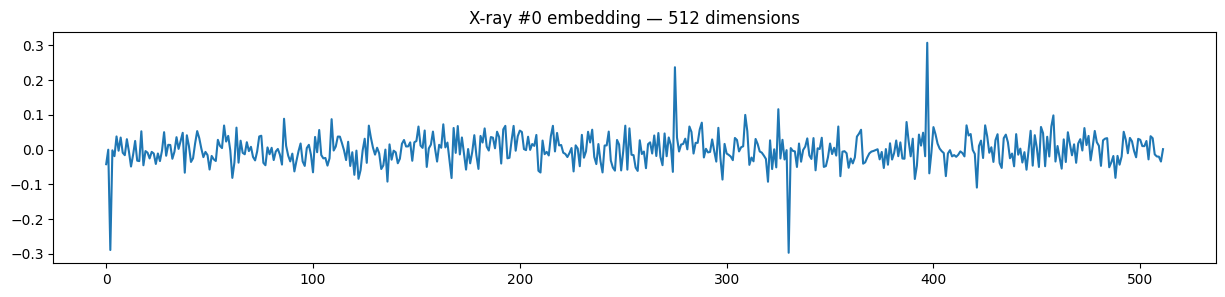

Min: -0.338  Max: 0.384  Mean: -0.001


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 3))
plt.plot(emb[0])
plt.title("X-ray #0 embedding — 512 dimensions")
plt.show()

print(f"Min: {emb.min():.3f}  Max: {emb.max():.3f}  Mean: {emb.mean():.3f}")

#WHAT IS MIN AND MAX HERE (UNIQUE FEATURE OF EMBEDDINGS, FEATURE ACTIVATION INTERPRET)

Min: -0.338
The most negative feature value — that big dip you see around dimension ~5. This dimension strongly "fired" in the negative direction, meaning BiomedCLIP detected something very specific (like dark lung fields or air density).
Max: 0.384
The highest positive feature value — those two tall spikes around dimensions ~260 and ~400. These dimensions detected something prominent in this X-ray (could be heart size, opacity, or rib structure).
Mean: -0.001
The average of all 512 numbers is almost exactly zero. This is expected because of L2 normalization — the values balance out around zero. It confirms the embedding is correctly normalized.


In [7]:
import json

with open("./index/metadata.json") as f:
    metadata = json.load(f)

# Search for similar X-rays to image #0
query = emb[0:1]
sims, idxs = index.search(query, k=6)

print("Top 5 similar X-rays to image #0:\n")
for rank, (sim, idx) in enumerate(zip(sims[0][1:], idxs[0][1:]), 1):
    meta = metadata[str(idx)]
    print(f"#{rank}  similarity={sim:.4f}  {meta['filename']}  →  {meta['labels']}")

Top 5 similar X-rays to image #0:

#1  similarity=0.9658  view1_frontal.jpg  →  Unknown
#2  similarity=0.9655  view1_frontal.jpg  →  Unknown
#3  similarity=0.9654  view1_frontal.jpg  →  Unknown
#4  similarity=0.9644  view1_frontal.jpg  →  Unknown
#5  similarity=0.9628  view1_frontal.jpg  →  Unknown


In [8]:
import pandas as pd
df = pd.read_csv("./data/train.csv")
print(df.columns.tolist())
print(df.head(2))

['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']
                                                Path     Sex  Age  \
0  CheXpert-v1.0-small/train/patient00001/study1/...  Female   68   
1  CheXpert-v1.0-small/train/patient00002/study2/...  Female   87   

  Frontal/Lateral AP/PA  No Finding  Enlarged Cardiomediastinum  Cardiomegaly  \
0         Frontal    AP         1.0                         NaN           NaN   
1         Frontal    AP         NaN                         NaN          -1.0   

   Lung Opacity  Lung Lesion  Edema  Consolidation  Pneumonia  Atelectasis  \
0           NaN          NaN    NaN            NaN        NaN          NaN   
1           1.0          NaN   -1.0           -1.0        NaN         -1.0   

   Pneumothorax  Pleural Effusion

In [9]:
print("Top 5 similar X-rays to image #0:\n")
for rank, (sim, idx) in enumerate(zip(sims[0][1:], idxs[0][1:]), 1):
    meta = metadata[str(idx)]
    # Show patient folder instead of filename
    path_parts = meta['filepath'].split('/')
    patient = '/'.join(path_parts[-3:])  # patient/study/view
    print(f"#{rank}  similarity={sim:.4f}  {patient}  →  {meta['labels']}")

Top 5 similar X-rays to image #0:

#1  similarity=0.9658  patient11660/study24/view1_frontal.jpg  →  Unknown
#2  similarity=0.9655  patient10487/study4/view1_frontal.jpg  →  Unknown
#3  similarity=0.9654  patient19087/study2/view1_frontal.jpg  →  Unknown
#4  similarity=0.9644  patient37793/study1/view1_frontal.jpg  →  Unknown
#5  similarity=0.9628  patient57065/study1/view1_frontal.jpg  →  Unknown


Below is updating metadata.json — replacing all those "Unknown" labels with real diagnoses. Here's what changes:
Before:
#1  similarity=0.9658  view1_frontal.jpg  →  Unknown
#2  similarity=0.9655  view1_frontal.jpg  →  Unknown
After:
#1  similarity=0.9658  view1_frontal.jpg  →  Pleural Effusion, Support Devices
#2  similarity=0.9655  view1_frontal.jpg  →  Cardiomegaly
Slow because it's looping through 223,415 metadata entries × CSV rows to match paths. It only runs once and saves permanently to metadata.json.
After this your results will show real clinical diagnoses which is the core of the RAG system — "8 similar past cases all had Pleural Effusion → high confidence diagnosis."

In [10]:
import pandas as pd
import json

# Disease columns
diseases = ['No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
            'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
            'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
            'Pleural Other', 'Fracture', 'Support Devices']

df = pd.read_csv("./data/train.csv")

# Build path → label string lookup
def get_labels(row):
    positive = [d for d in diseases if row.get(d) == 1.0]
    uncertain = [d for d in diseases if row.get(d) == -1.0]
    if positive:
        return ", ".join(positive)
    elif uncertain:
        return "Uncertain: " + ", ".join(uncertain)
    return "No Finding"

df["label_str"] = df.apply(get_labels, axis=1)

# Fix path format to match metadata
df["path_key"] = df["Path"].apply(lambda x: x.split("/")[-1])
label_map = dict(zip(df["Path"], df["label_str"]))

# Update metadata.json
with open("./index/metadata.json") as f:
    metadata = json.load(f)

fixed = 0
for idx, entry in metadata.items():
    # Match by partial path
    for csv_path, label in label_map.items():
        if entry["filename"] in csv_path and entry["filepath"].split("train/")[-1].split("/view")[0] in csv_path:
            entry["labels"] = label
            fixed += 1
            break

with open("./index/metadata.json", "w") as f:
    json.dump(metadata, f)

print(f"Fixed labels for {fixed:,} images")

Fixed labels for 223,007 images


In [ ]:
print("Top 5 similar X-rays to image #0:\n")
for rank, (sim, idx) in enumerate(zip(sims[0][1:], idxs[0][1:]), 1):
    meta = metadata[str(idx)]
    # Show patient folder instead of filename
    path_parts = meta['filepath'].split('/')
    patient = '/'.join(path_parts[-3:])  # patient/study/view
    print(f"#{rank}  similarity={sim:.4f}  {patient}  →  {meta['labels']}")

Top 5 similar X-rays to image #0:

#1  similarity=0.9658  patient11660/study24/view1_frontal.jpg  →  Lung Opacity
#2  similarity=0.9655  patient10487/study4/view1_frontal.jpg  →  Lung Opacity, Support Devices
#3  similarity=0.9654  patient19087/study2/view1_frontal.jpg  →  Enlarged Cardiomediastinum, Lung Opacity, Pneumothorax, Pleural Effusion
#4  similarity=0.9644  patient37793/study1/view1_frontal.jpg  →  No Finding, Support Devices
#5  similarity=0.9628  patient57065/study1/view1_frontal.jpg  →  Cardiomegaly, Edema


1.0 Positive — condition IS presentCardiomegaly confirmed
-1.0 Uncertain — maybe present, unclear Edema possibly present
0.0 Negative — condition NOT presentNo Pneumonia
NaN Not mentioned — radiologist didn't comment

Image #0 is the very first X-ray in CheXpert dataset — whatever image was indexed first when gallery_builder.py scanned the folder.
In the code:
pythonquery = emb[0:1]  # ← this is "image #0"
It's grabbing the first row of embeddings matrix — the 512-number fingerprint of the first X-ray encoded.
To see which patient it actually is:
pythonprint("Query image (image #0):")
print(f"  File:    {metadata['0']['filename']}")
print(f"  Path:    {metadata['0']['filepath']}")
print(f"  Labels:  {metadata['0']['labels']}")
```
ex: patient00001/study1/view1_frontal.jpg
The search then finds the 5 most visually similar X-rays to that first patient's scan from across all 223,415 images.
In the real web app, "image #0" will be replaced by whatever X-ray the doctor uploads.

In [12]:
print("Top 5 similar X-rays to image #2:\n")
for rank, (sim, idx) in enumerate(zip(sims[0][1:], idxs[0][1:]), 1):
    meta = metadata[str(idx)]
    # Show patient folder instead of filename
    path_parts = meta['filepath'].split('/')
    patient = '/'.join(path_parts[-3:])  # patient/study/view
    print(f"#{rank}  similarity={sim:.4f}  {patient}  →  {meta['labels']}")

Top 5 similar X-rays to image #2:

#1  similarity=0.9658  patient11660/study24/view1_frontal.jpg  →  Lung Opacity
#2  similarity=0.9655  patient10487/study4/view1_frontal.jpg  →  Lung Opacity, Support Devices
#3  similarity=0.9654  patient19087/study2/view1_frontal.jpg  →  Enlarged Cardiomediastinum, Lung Opacity, Pneumothorax, Pleural Effusion
#4  similarity=0.9644  patient37793/study1/view1_frontal.jpg  →  No Finding, Support Devices
#5  similarity=0.9628  patient57065/study1/view1_frontal.jpg  →  Cardiomegaly, Edema


In [16]:
#df = pd.read_csv("./data/train.csv")
df['Path'].iloc[0]

'CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg'

In [17]:
df.loc[df['Path'].str.contains("CheXpert-v1.0-small/train/patient11660/study1/view1_frontal.jpg")]

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,...,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,label_str,path_key
48115,CheXpert-v1.0-small/train/patient11660/study1/...,Female,50,Frontal,AP,NaN,NaN,NaN,NaN,NaN,...,-1.0,NaN,-1.0,NaN,1.0,NaN,NaN,NaN,Pleural Effusion,view1_frontal.jpg


In [19]:
import pandas as pd
import json

diseases = ['No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly',
            'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation',
            'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion',
            'Pleural Other', 'Fracture', 'Support Devices']

df = pd.read_csv("./data/train.csv")

def get_labels(row):
    results = []
    for d in diseases:
        val = row.get(d)
        if val == 1.0:
            results.append(f"{d}: Positive")
        elif val == -1.0:
            results.append(f"{d}: Uncertain")
        elif val == 0.0:
            results.append(f"{d}: Negative")
    return " | ".join(results) if results else "Not mentioned"

df["label_str"] = df.apply(get_labels, axis=1)

# Fast lookup: extract just patient/study/view as key
df["path_short"] = df["Path"].apply(lambda x: "/".join(x.split("/")[-3:]))
label_map = dict(zip(df["path_short"], df["label_str"]))

with open("./index/metadata.json") as f:
    metadata = json.load(f)

fixed = 0
for idx, entry in metadata.items():
    # Extract last 3 parts of filepath as key
    key = "/".join(entry["filepath"].split("/")[-3:])
    if key in label_map:
        entry["labels"] = label_map[key]
        fixed += 1

with open("./index/metadata.json", "w") as f:
    json.dump(metadata, f)

print(f"Fixed labels for {fixed:,} images")

Fixed labels for 223,007 images


In [20]:
#df = pd.read_csv("./data/train.csv")
df['Path'].iloc[0]

'CheXpert-v1.0-small/train/patient00001/study1/view1_frontal.jpg'

In [21]:
df.loc[df['Path'].str.contains("CheXpert-v1.0-small/train/patient11660/study1/view1_frontal.jpg")]

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,...,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,label_str,path_short
48115,CheXpert-v1.0-small/train/patient11660/study1/...,Female,50,Frontal,AP,NaN,NaN,NaN,NaN,NaN,...,-1.0,NaN,-1.0,NaN,1.0,NaN,NaN,NaN,Consolidation: Uncertain | Atelectasis: Uncert...,patient11660/study1/view1_frontal.jpg


In [22]:
print("Top 5 similar X-rays to image #2:\n")
for rank, (sim, idx) in enumerate(zip(sims[0][1:], idxs[0][1:]), 1):
    meta = metadata[str(idx)]
    # Show patient folder instead of filename
    path_parts = meta['filepath'].split('/')
    patient = '/'.join(path_parts[-3:])  # patient/study/view
    print(f"#{rank}  similarity={sim:.4f}  {patient}  →  {meta['labels']}")

Top 5 similar X-rays to image #2:

#1  similarity=0.9658  patient11660/study24/view1_frontal.jpg  →  Lung Opacity: Positive | Consolidation: Negative | Pneumothorax: Negative | Pleural Effusion: Negative
#2  similarity=0.9655  patient10487/study4/view1_frontal.jpg  →  Lung Opacity: Positive | Consolidation: Uncertain | Atelectasis: Uncertain | Support Devices: Positive
#3  similarity=0.9654  patient19087/study2/view1_frontal.jpg  →  Enlarged Cardiomediastinum: Positive | Lung Opacity: Positive | Pneumothorax: Positive | Pleural Effusion: Positive
#4  similarity=0.9644  patient37793/study1/view1_frontal.jpg  →  No Finding: Positive | Enlarged Cardiomediastinum: Negative | Pneumothorax: Negative | Support Devices: Positive
#5  similarity=0.9628  patient57065/study1/view1_frontal.jpg  →  Cardiomegaly: Positive | Lung Opacity: Negative | Edema: Positive


embeddings_checkpoint.npy
┌─────────────────────────────┐
│ 223,415 rows × 512 columns  │
│ each row = one X-ray        │
│ each column = one feature   │
│ → These ARE the vectors     │
└─────────────────────────────┘

visual_db.index
┌─────────────────────────────┐
│ FAISS index built on top    │
│ of the embeddings           │
│ → Enables fast search       │
│ → "find similar vectors"    │
└─────────────────────────────┘

metadata.json
┌─────────────────────────────┐
│ 223,415 entries             │
│ each entry = {              │
│   filename: "view1..."      │
│   filepath: "/Users/..."    │
│   labels:  "Pneumonia:..."  │
│   idx: 0                    │
│ }                           │
│ → NOT vectors, just info    │
│ → links FAISS ID → labels   │
└─────────────────────────────┘

Shape: (223007, 512)


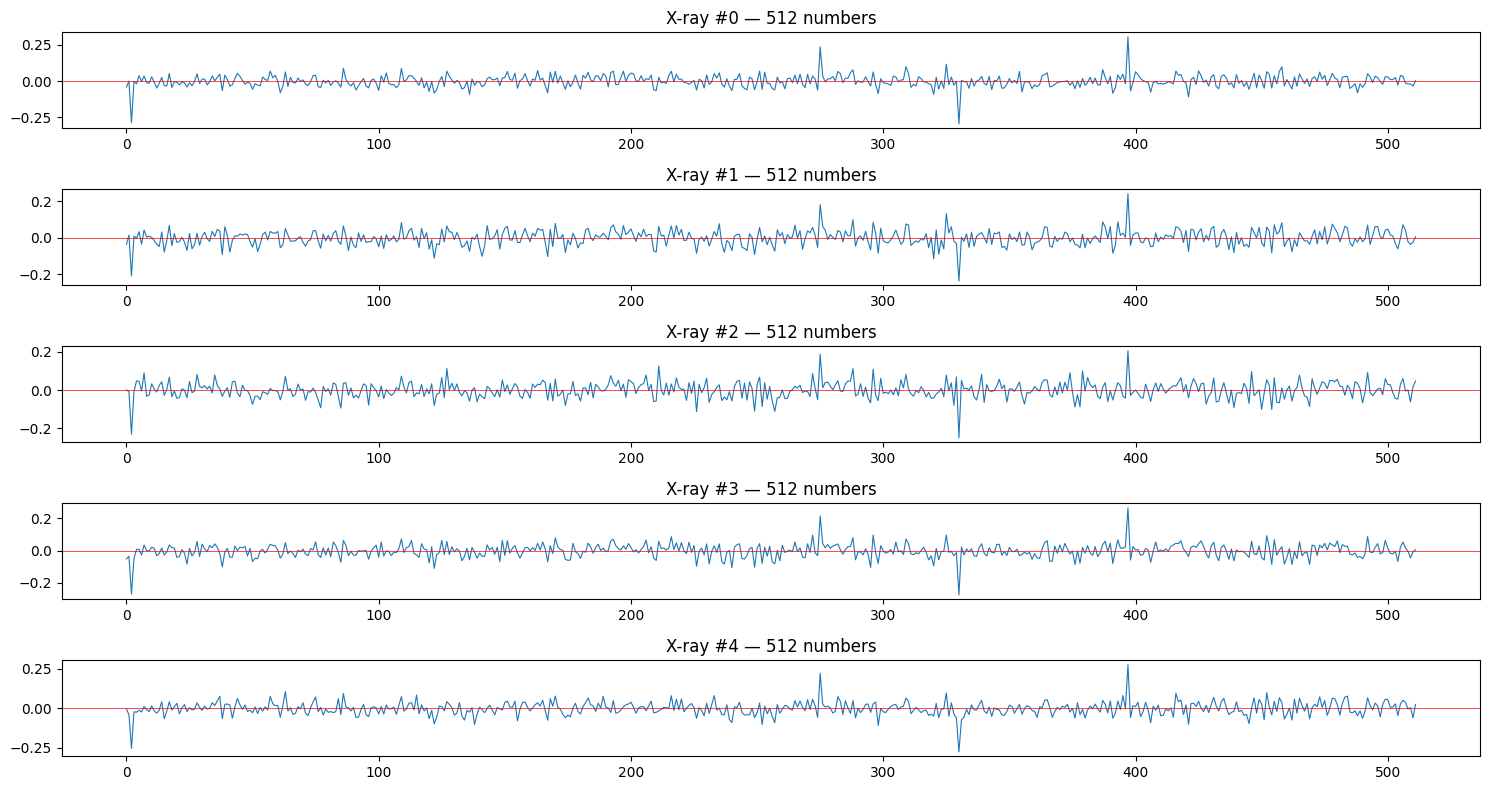

↑ Each line = one X-ray's fingerprint


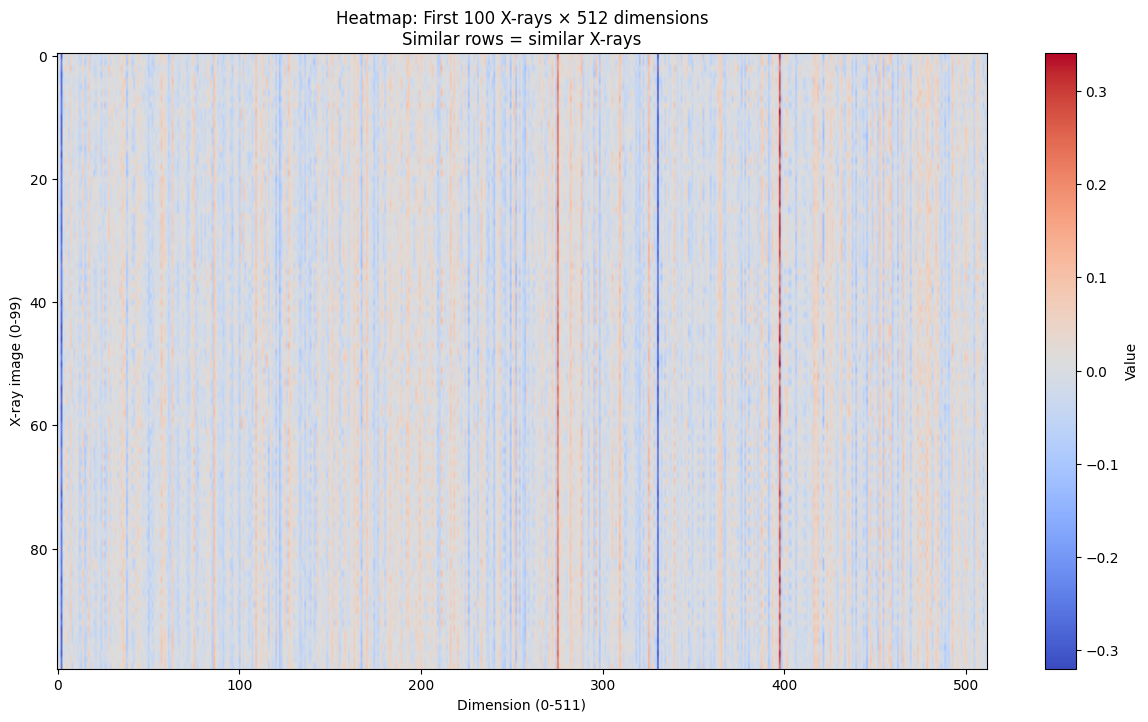

↑ Similar colored rows = similar X-rays
Running PCA on 5,000 samples (takes ~10 seconds)...


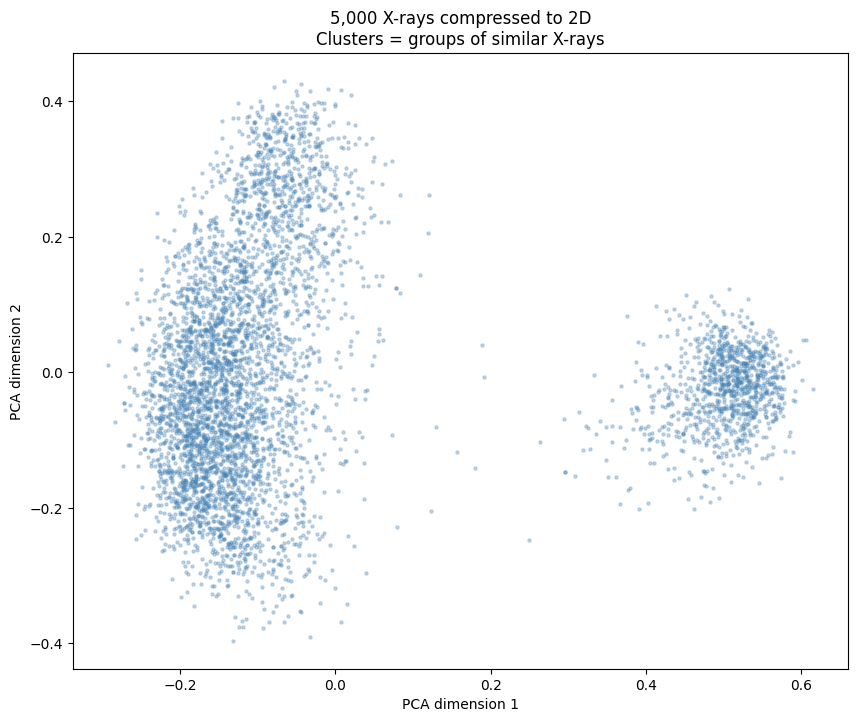

↑ Each dot = one X-ray. Close dots = similar images


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load embeddings
emb = np.load("./index/embeddings_checkpoint.npy")
print(f"Shape: {emb.shape}")  # (223415, 512)

# ── 1. Show raw numbers for first 5 X-rays ──
fig, axes = plt.subplots(5, 1, figsize=(15, 8))
for i in range(5):
    axes[i].plot(emb[i], linewidth=0.8)
    axes[i].set_title(f"X-ray #{i} — 512 numbers")
    axes[i].axhline(y=0, color='red', linewidth=0.5)
plt.tight_layout()
plt.savefig("embeddings_raw.png", dpi=150)
plt.show()
print("↑ Each line = one X-ray's fingerprint")

# ── 2. Heatmap of first 100 X-rays ──
plt.figure(figsize=(15, 8))
plt.imshow(emb[:100], aspect='auto', cmap='coolwarm')
plt.colorbar(label='Value')
plt.xlabel("Dimension (0-511)")
plt.ylabel("X-ray image (0-99)")
plt.title("Heatmap: First 100 X-rays × 512 dimensions\nSimilar rows = similar X-rays")
plt.savefig("embeddings_heatmap.png", dpi=150)
plt.show()
print("↑ Similar colored rows = similar X-rays")

# ── 3. PCA: compress 512 → 2 dimensions to visualize clusters ──
print("Running PCA on 5,000 samples (takes ~10 seconds)...")
sample = emb[:5000]
pca = PCA(n_components=2)
reduced = pca.fit_transform(sample)

plt.figure(figsize=(10, 8))
plt.scatter(reduced[:, 0], reduced[:, 1], 
            alpha=0.3, s=5, c='steelblue')
plt.xlabel("PCA dimension 1")
plt.ylabel("PCA dimension 2")
plt.title("5,000 X-rays compressed to 2D\nClusters = groups of similar X-rays")
plt.savefig("embeddings_pca.png", dpi=150)
plt.show()
print("↑ Each dot = one X-ray. Close dots = similar images")

In [27]:
import subprocess
subprocess.run(["pip", "install", "scikit-learn"], check=True)


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


CompletedProcess(args=['pip', 'install', 'scikit-learn'], returncode=0)

In [1]:
import torch
import open_clip
import numpy as np
from PIL import Image

# ── Load BiomedCLIP (already cached, no download) ──
model, _, transform = open_clip.create_model_and_transforms(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)
tokenizer = open_clip.get_tokenizer(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)
model.eval()

# ── 14 CheXpert disease prompts ──
DISEASES = {
    "No Finding":                   "Chest X-ray with no abnormality, normal findings",
    "Enlarged Cardiomediastinum":   "Chest X-ray showing enlarged cardiomediastinum",
    "Cardiomegaly":                 "Chest X-ray showing cardiomegaly, enlarged heart",
    "Lung Opacity":                 "Chest X-ray showing lung opacity",
    "Lung Lesion":                  "Chest X-ray showing lung lesion or mass",
    "Edema":                        "Chest X-ray showing pulmonary edema, fluid in lungs",
    "Consolidation":                "Chest X-ray showing consolidation in lung",
    "Pneumonia":                    "Chest X-ray showing pneumonia, lung infection",
    "Atelectasis":                  "Chest X-ray showing atelectasis, collapsed lung",
    "Pneumothorax":                 "Chest X-ray showing pneumothorax, air in pleural space",
    "Pleural Effusion":             "Chest X-ray showing pleural effusion, fluid around lung",
    "Pleural Other":                "Chest X-ray showing pleural abnormality",
    "Fracture":                     "Chest X-ray showing rib fracture or bone fracture",
    "Support Devices":              "Chest X-ray showing support devices, tubes or lines",
}

# ── Encode text prompts once (reuse for all images) ──
print("Encoding disease text prompts...")
with torch.no_grad():
    text_tokens = tokenizer(list(DISEASES.values()))
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
print(f"Text features shape: {text_features.shape}")  # (14, 512)


# ── Probability function ──
@torch.no_grad()
def predict_diseases(image_path: str, top_k: int = 5) -> dict:
    """
    Input:  Path to chest X-ray image
    Output: Dictionary of disease → probability score
    
    Example:
        {
            "Pleural Effusion": 0.82,
            "Cardiomegaly":     0.71,
            "Edema":            0.45,
            ...
        }
    """
    # Load + preprocess image
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0)
    
    # Encode image
    image_features = model.encode_image(img_tensor)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    
    # Cosine similarity → probabilities
    similarities = (image_features @ text_features.T).squeeze(0)
    probs = torch.softmax(similarities * 100, dim=0).numpy()
    
    # Build result dictionary
    disease_names = list(DISEASES.keys())
    results = {disease_names[i]: round(float(probs[i]) * 100, 2) 
               for i in range(len(disease_names))}
    
    # Sort by probability
    results = dict(sorted(results.items(), key=lambda x: x[1], reverse=True))
    return results


# ── Test on a real image ──
import os, json

# Grab first image from metadata
with open("./index/metadata.json") as f:
    metadata = json.load(f)

test_image = metadata["0"]["filepath"]
print(f"\nTesting on: {test_image}")
print("=" * 55)

probs = predict_diseases(test_image)

print(f"{'Disease':<30} {'Probability':>10}")
print("-" * 45)
for disease, prob in probs.items():
    bar = "█" * int(prob / 2)
    print(f"{disease:<30} {prob:>8.2f}%  {bar}")

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Encoding disease text prompts...
Text features shape: torch.Size([14, 512])

Testing on: /Users/nurgulbagitovagmail.com/Documents/MSITM Lecture notes/Spring 2026/Gen AI I/MedRAG/data/train/patient00001/study1/view1_frontal.jpg
Disease                        Probability
---------------------------------------------
Lung Opacity                      38.90%  ███████████████████
Pleural Other                     21.18%  ██████████
Consolidation                     15.26%  ███████
Fracture                          12.34%  ██████
Edema                              3.89%  █
Pneumonia                          2.93%  █
Pleural Effusion                   2.26%  █
Lung Lesion                        1.85%  
Enlarged Cardiomediastinum         0.38%  
Atelectasis                        0.33%  
Support Devices                    0.27%  
No Finding                         0.26%  
Pneumothorax                       0.14%  
Cardiomegaly                       0.00%  


In [2]:
import os, json, torch, faiss, numpy as np
from PIL import Image
import open_clip
from pathlib import Path

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# ════════════════════════════════════════════════
# SETUP — load everything once
# ════════════════════════════════════════════════

print("Loading BiomedCLIP...")
model, _, transform = open_clip.create_model_and_transforms(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)
tokenizer = open_clip.get_tokenizer(
    "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
)
model.eval()

print("Loading FAISS index...")
index = faiss.read_index("./index/visual_db.index")

print("Loading metadata...")
with open("./index/metadata.json") as f:
    metadata = json.load(f)

# ── 14 disease prompts ──
DISEASES = {
    "No Finding":                 "Chest X-ray with no abnormality, normal findings",
    "Enlarged Cardiomediastinum": "Chest X-ray showing enlarged cardiomediastinum",
    "Cardiomegaly":               "Chest X-ray showing cardiomegaly, enlarged heart",
    "Lung Opacity":               "Chest X-ray showing lung opacity",
    "Lung Lesion":                "Chest X-ray showing lung lesion or mass",
    "Edema":                      "Chest X-ray showing pulmonary edema, fluid in lungs",
    "Consolidation":              "Chest X-ray showing consolidation in lung",
    "Pneumonia":                  "Chest X-ray showing pneumonia, lung infection",
    "Atelectasis":                "Chest X-ray showing atelectasis, collapsed lung",
    "Pneumothorax":               "Chest X-ray showing pneumothorax, air in pleural space",
    "Pleural Effusion":           "Chest X-ray showing pleural effusion, fluid around lung",
    "Pleural Other":              "Chest X-ray showing pleural abnormality",
    "Fracture":                   "Chest X-ray showing rib fracture or bone fracture",
    "Support Devices":            "Chest X-ray showing support devices, tubes or lines",
}

# Encode text prompts once
with torch.no_grad():
    text_tokens = tokenizer(list(DISEASES.values()))
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print("✅ System ready!\n")


# ════════════════════════════════════════════════
# PERSON A — Visual Search
# ════════════════════════════════════════════════

@torch.no_grad()
def get_image_embedding(image_path: str) -> np.ndarray:
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0)
    features = model.encode_image(tensor)
    features = features / features.norm(dim=-1, keepdim=True)
    return features.numpy().astype(np.float32)


def visual_search(image_path: str, top_k: int = 5) -> list:
    """Person A: Input image → 5 similar past cases"""
    query_emb = get_image_embedding(image_path)
    sims, idxs = index.search(query_emb, top_k + 1)
    
    results = []
    for sim, idx in zip(sims[0][1:], idxs[0][1:]):  # skip self
        meta = metadata[str(idx)]
        results.append({
            "similarity": round(float(sim), 4),
            "filepath":   meta["filepath"],
            "labels":     meta["labels"],
            "patient":    "/".join(meta["filepath"].split("/")[-3:])
        })
    return results


# ════════════════════════════════════════════════
# PERSON B — Zero-Shot Classifier
# ════════════════════════════════════════════════

@torch.no_grad()
def predict_diseases(image_path: str) -> dict:
    """Person B: Input image → disease probabilities"""
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0)
    
    image_features = model.encode_image(tensor)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    
    similarities = (image_features @ text_features.T).squeeze(0)
    probs = torch.softmax(similarities * 100, dim=0).numpy()
    
    disease_names = list(DISEASES.keys())
    results = {disease_names[i]: round(float(probs[i]) * 100, 2)
               for i in range(len(disease_names))}
    return dict(sorted(results.items(), key=lambda x: x[1], reverse=True))


# ════════════════════════════════════════════════
# CROSSCHECK — Compare & Validate
# ════════════════════════════════════════════════

# Medical synonym map
SYNONYMS = {
    "Pleural Effusion":           ["pleural fluid", "fluid around lung", "effusion"],
    "Cardiomegaly":               ["enlarged heart", "cardiac enlargement"],
    "Pneumonia":                  ["lung infection", "consolidation"],
    "Edema":                      ["fluid in lungs", "pulmonary edema"],
    "Atelectasis":                ["collapsed lung", "lung collapse"],
    "Lung Opacity":               ["opacity", "haziness", "infiltrate"],
    "No Finding":                 ["normal", "no abnormality", "clear"],
}

def labels_match(llm_disease: str, gallery_label_str: str) -> bool:
    """Check if LLM disease matches gallery label using synonyms."""
    gallery_lower = gallery_label_str.lower()
    
    # Direct match
    if llm_disease.lower() in gallery_lower:
        return True
    
    # Synonym match
    for synonym in SYNONYMS.get(llm_disease, []):
        if synonym.lower() in gallery_lower:
            return True
    return False


def crosscheck(similar_cases: list, disease_probs: dict) -> dict:
    """
    Compare Person A (gallery labels) vs Person B (LLM probs)
    Returns confidence-scored diagnosis
    """
    top_diseases = list(disease_probs.keys())[:5]  # top 5 from LLM
    
    results = []
    for disease in top_diseases:
        llm_prob = disease_probs[disease]
        
        # Count how many similar cases agree
        matching_cases = 0
        total_cases = len(similar_cases)
        
        for case in similar_cases:
            if labels_match(disease, case["labels"]):
                matching_cases += 1
        
        gallery_support = matching_cases / total_cases  # 0.0 to 1.0
        
        # Weighted confidence score
        confidence = (llm_prob / 100 * 0.5) + (gallery_support * 0.5)
        
        # Validation status
        if gallery_support >= 0.6 and llm_prob >= 20:
            status = "HIGH"
        elif gallery_support >= 0.3 or llm_prob >= 15:
            status = "MEDIUM"
        else:
            status = "LOW"
        
        results.append({
            "disease":         disease,
            "llm_probability": llm_prob,
            "gallery_support": f"{matching_cases}/{total_cases} cases",
            "confidence":      round(confidence * 100, 1),
            "status":          status,
        })
    
    return sorted(results, key=lambda x: x["confidence"], reverse=True)


# ════════════════════════════════════════════════
# FULL PIPELINE — run everything
# ════════════════════════════════════════════════

def analyze_xray(image_path: str):
    print(f"\n{'='*60}")
    print(f"ANALYZING: {Path(image_path).name}")
    print(f"{'='*60}")
    
    # Person A
    print("\n[PERSON A] Finding similar cases...")
    similar_cases = visual_search(image_path, top_k=5)
    
    # Person B
    print("[PERSON B] Running zero-shot classification...")
    disease_probs = predict_diseases(image_path)
    
    # Crosscheck
    print("[CROSSCHECK] Validating...\n")
    diagnosis = crosscheck(similar_cases, disease_probs)
    
    # ── Print results ──
    print("📋 DIFFERENTIAL DIAGNOSIS")
    print("-" * 60)
    for i, d in enumerate(diagnosis):
        tag = "PRIMARY  " if i == 0 else "CONSIDER "
        print(f"{tag} {d['disease']}")
        print(f"          LLM: {d['llm_probability']}%  |  "
              f"Gallery: {d['gallery_support']}  |  "
              f"Confidence: {d['confidence']}%  [{d['status']}]")
    
    print("\n🔍 SIMILAR PAST CASES")
    print("-" * 60)
    for i, case in enumerate(similar_cases, 1):
        print(f"  #{i}  sim={case['similarity']}  {case['patient']}")
        # Show only positive labels
        positives = [l.split(":")[0] for l in case['labels'].split(" | ") 
                     if "Positive" in l]
        print(f"       Confirmed: {', '.join(positives) if positives else 'None'}")
    
    return {"diagnosis": diagnosis, "similar_cases": similar_cases}


# ── Run on test image ──
test_image = metadata["2"]["filepath"]
result = analyze_xray(test_image)

Loading BiomedCLIP...
Loading FAISS index...
Loading metadata...
✅ System ready!


ANALYZING: view2_lateral.jpg

[PERSON A] Finding similar cases...
[PERSON B] Running zero-shot classification...
[CROSSCHECK] Validating...

📋 DIFFERENTIAL DIAGNOSIS
------------------------------------------------------------
PRIMARY   Atelectasis
          LLM: 38.95%  |  Gallery: 2/5 cases  |  Confidence: 39.5%  [MEDIUM]
CONSIDER  Lung Opacity
          LLM: 9.97%  |  Gallery: 3/5 cases  |  Confidence: 35.0%  [MEDIUM]
CONSIDER  Pneumothorax
          LLM: 7.2%  |  Gallery: 1/5 cases  |  Confidence: 13.6%  [LOW]
CONSIDER  Fracture
          LLM: 25.91%  |  Gallery: 0/5 cases  |  Confidence: 13.0%  [MEDIUM]
CONSIDER  Lung Lesion
          LLM: 5.98%  |  Gallery: 0/5 cases  |  Confidence: 3.0%  [LOW]

🔍 SIMILAR PAST CASES
------------------------------------------------------------
  #1  sim=0.9392  patient30555/study1/view2_lateral.jpg
       Confirmed: Cardiomegaly
  #2  sim=0.939  patient29670/study1/